<a href="https://colab.research.google.com/github/weagan/Convolutional-Neural-Networks/blob/main/Neural_Thicket_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Neural Thicket Demo

This notebook demonstrates the core idea of Neural Thickets:

- Many good solutions exist near pretrained weights
- We can sample LoRA perturbations
- Select top-performing ones
- Combine them for improved performance

We will:
1. Load a small model
2. Create random LoRA adapters
3. Evaluate many candidates
4. Select top-K
5. Compare single vs ensemble


In [1]:
!pip install transformers datasets peft evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import evaluate
from peft import LoraConfig, get_peft_model
from copy import deepcopy

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Load Dataset (SST-2)

In [3]:
dataset = load_dataset("glue", "sst2")
metric = evaluate.load("glue", "sst2")

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

## Load Base Model

In [4]:
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
base_model.eval()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Function: Evaluate Model

In [5]:
def evaluate_model(model):
    model.eval()
    preds, labels = [], []

    for batch in dataset["validation"]:
        input_ids = batch["input_ids"].unsqueeze(0).to(device)
        attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
        label = batch["label"]

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

        pred = torch.argmax(logits, dim=-1).item()
        preds.append(pred)
        labels.append(label)

    return metric.compute(predictions=preds, references=labels)["accuracy"]

## Create Random LoRA Model

In [6]:
def create_lora_model(base_model, rank=16, scale=0.1):
    model = deepcopy(base_model)

    config = LoraConfig(
        r=rank,
        lora_alpha=rank,
        target_modules=["q_lin", "v_lin"],
        lora_dropout=0.0,
        bias="none"
    )

    model = get_peft_model(model, config)

    # Randomize LoRA weights (Neural Thicket idea)
    for name, param in model.named_parameters():
        if "lora" in name:
            param.data = scale * torch.randn_like(param)

    return model.to(device)

## Sample Many Candidates

In [7]:
NUM_SAMPLES = 20

candidates = []

for i in range(NUM_SAMPLES):
    model = create_lora_model(base_model)
    acc = evaluate_model(model)
    print(f"Model {i}: {acc:.4f}")
    candidates.append((acc, model))

Model 0: 0.5034
Model 1: 0.4874
Model 2: 0.4920
Model 3: 0.4541
Model 4: 0.4908
Model 5: 0.4862
Model 6: 0.5092
Model 7: 0.5034
Model 8: 0.4908
Model 9: 0.5092
Model 10: 0.5206
Model 11: 0.4862
Model 12: 0.4667
Model 13: 0.5115
Model 14: 0.5115
Model 15: 0.5092
Model 16: 0.4885
Model 17: 0.5550
Model 18: 0.5172
Model 19: 0.4908


## Select Top-K (Thicket)

In [8]:
K = 4

candidates.sort(key=lambda x: x[0], reverse=True)
top_models = candidates[:K]

print("Top accuracies:")
for acc, _ in top_models:
    print(acc)

Top accuracies:
0.555045871559633
0.5206422018348624
0.5172018348623854
0.5114678899082569


## Ensemble (Neural Thicket)

In [9]:
def ensemble_predict(models):
    preds, labels = [], []

    for batch in dataset["validation"]:
        input_ids = batch["input_ids"].unsqueeze(0).to(device)
        attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
        label = batch["label"]

        logits_sum = 0

        for _, model in models:
            with torch.no_grad():
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            logits_sum += logits

        pred = torch.argmax(logits_sum, dim=-1).item()
        preds.append(pred)
        labels.append(label)

    return metric.compute(predictions=preds, references=labels)["accuracy"]

In [10]:
best_single = top_models[0][0]
ensemble_acc = ensemble_predict(top_models)

print("\n=== RESULTS ===")
print("Best Single Model:", best_single)
print("Thicket Ensemble:", ensemble_acc)


=== RESULTS ===
Best Single Model: 0.555045871559633
Thicket Ensemble: 0.5389908256880734


In [11]:
NUM_SAMPLES = 10

candidates = []

for i in range(NUM_SAMPLES):
    model = create_lora_model(base_model)
    acc = evaluate_model(model)
    print(f"Model {i}: {acc:.4f}")
    candidates.append((acc, model))

Model 0: 0.4862
Model 1: 0.5482
Model 2: 0.5057
Model 3: 0.4885
Model 4: 0.5149
Model 5: 0.4862
Model 6: 0.5126
Model 7: 0.4679
Model 8: 0.5103
Model 9: 0.5183


In [12]:
K = 2

candidates.sort(key=lambda x: x[0], reverse=True)
top_models = candidates[:K]

print("Top accuracies:")
for acc, _ in top_models:
    print(acc)

Top accuracies:
0.5481651376146789
0.518348623853211


In [13]:
best_single = top_models[0][0]
ensemble_acc = ensemble_predict(top_models)

print("\n=== RESULTS ===")
print("Best Single Model:", best_single)
print("Thicket Ensemble:", ensemble_acc)


=== RESULTS ===
Best Single Model: 0.5481651376146789
Thicket Ensemble: 0.5355504587155964


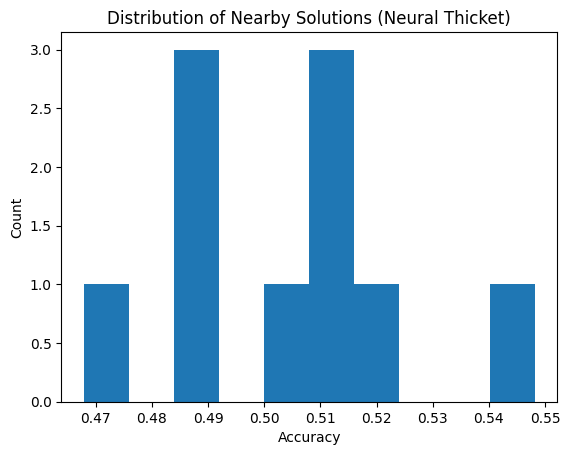

In [14]:
import matplotlib.pyplot as plt

accs = [x[0] for x in candidates]

plt.hist(accs, bins=10)
plt.title("Distribution of Nearby Solutions (Neural Thicket)")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.show()

## Visualization

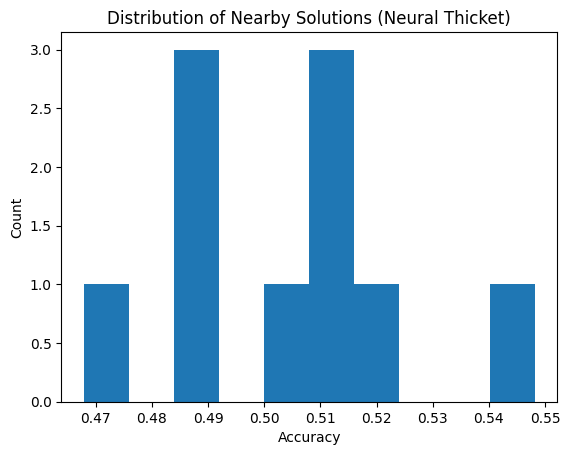

In [15]:
import matplotlib.pyplot as plt

accs = [x[0] for x in candidates]

plt.hist(accs, bins=10)
plt.title("Distribution of Nearby Solutions (Neural Thicket)")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.show()